# 126.674 ríos medidos desde el espacio. ¿Cuánta agua guardan?

Sabíamos cuánta agua hay en lagos y glaciares. Pero los ríos — la fuente más renovable — eran un misterio. Un satélite acaba de medirlos todos a la vez por primera vez.

---

**Paper:** Wade et al. (2026) — *Wide-swath altimetry maps bank shapes and storage changes in global rivers*
**Journal:** Nature | **DOI:** [10.1038/s41586-026-10218-y](https://doi.org/10.1038/s41586-026-10218-y)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-12-rios-swot-126mil-volumen/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/watch?v=_oyYJWis70w)

## ¿Qué midieron?

El satélite **SWOT** (Surface Water and Ocean Topography) mide la altura y el ancho del agua en ríos de todo el mundo usando radar de banda Ka. Durante su primer año en órbita (octubre 2023 – septiembre 2024), observó **126.674 tramos fluviales** — el 73% de los ríos de más de 30 metros de ancho del planeta.

Con esas mediciones calcularon la **anomalía de almacenamiento fluvial** (RSA): cuánto sube y baja el volumen de agua en cada tramo, cada mes. Hasta ahora solo podíamos estimarlo con modelos.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
DRSA_GLOBAL = 313.1          # ΔRSA global SWOT (km³)
DRSA_GLOBAL_ERR = 129.5      # Incertidumbre (km³)
MODELO_BAJO = 436.7          # MeanDRS escenario bajo (km³)
FUENTE = 'Fuente: Wade et al. (2026), Nature | DOI: 10.1038/s41586-026-10218-y'

COLOR_SWOT = '#2563EB'       # Azul CaM — datos SWOT
COLOR_MODELO = '#DC2626'     # Rojo — modelos previos
COLOR_CONTEXTO = '#059669'   # Emerald — contexto
COLOR_ALERTA = '#D97706'     # Amber — referencia

# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Estilo CaM
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
cuencas = pd.read_csv('datos/cuencas_rsa.csv')
comparacion = pd.read_csv('datos/comparacion_global.csv')
contexto = pd.read_csv('datos/contexto_agua.csv')
metricas = pd.read_csv('datos/metricas_swot.csv')

print(f"Cuencas: {len(cuencas)} ríos principales")
print(f"Comparación SWOT vs modelos: {len(comparacion)} registros")
print(f"ΔRSA global SWOT: {DRSA_GLOBAL} ± {DRSA_GLOBAL_ERR} km³")
print(f"MeanDRS escenario bajo: {MODELO_BAJO} km³")
print(f"Diferencia: {(DRSA_GLOBAL - MODELO_BAJO) / MODELO_BAJO * 100:.1f}%")

Cuencas: 6 ríos principales
Comparación SWOT vs modelos: 9 registros
ΔRSA global SWOT: 313.1 ± 129.5 km³
MeanDRS escenario bajo: 436.7 km³
Diferencia: -28.3%


## Las cuencas que mueven el mundo

Veamos cuánta agua almacenan las 6 cuencas con mayor variabilidad.

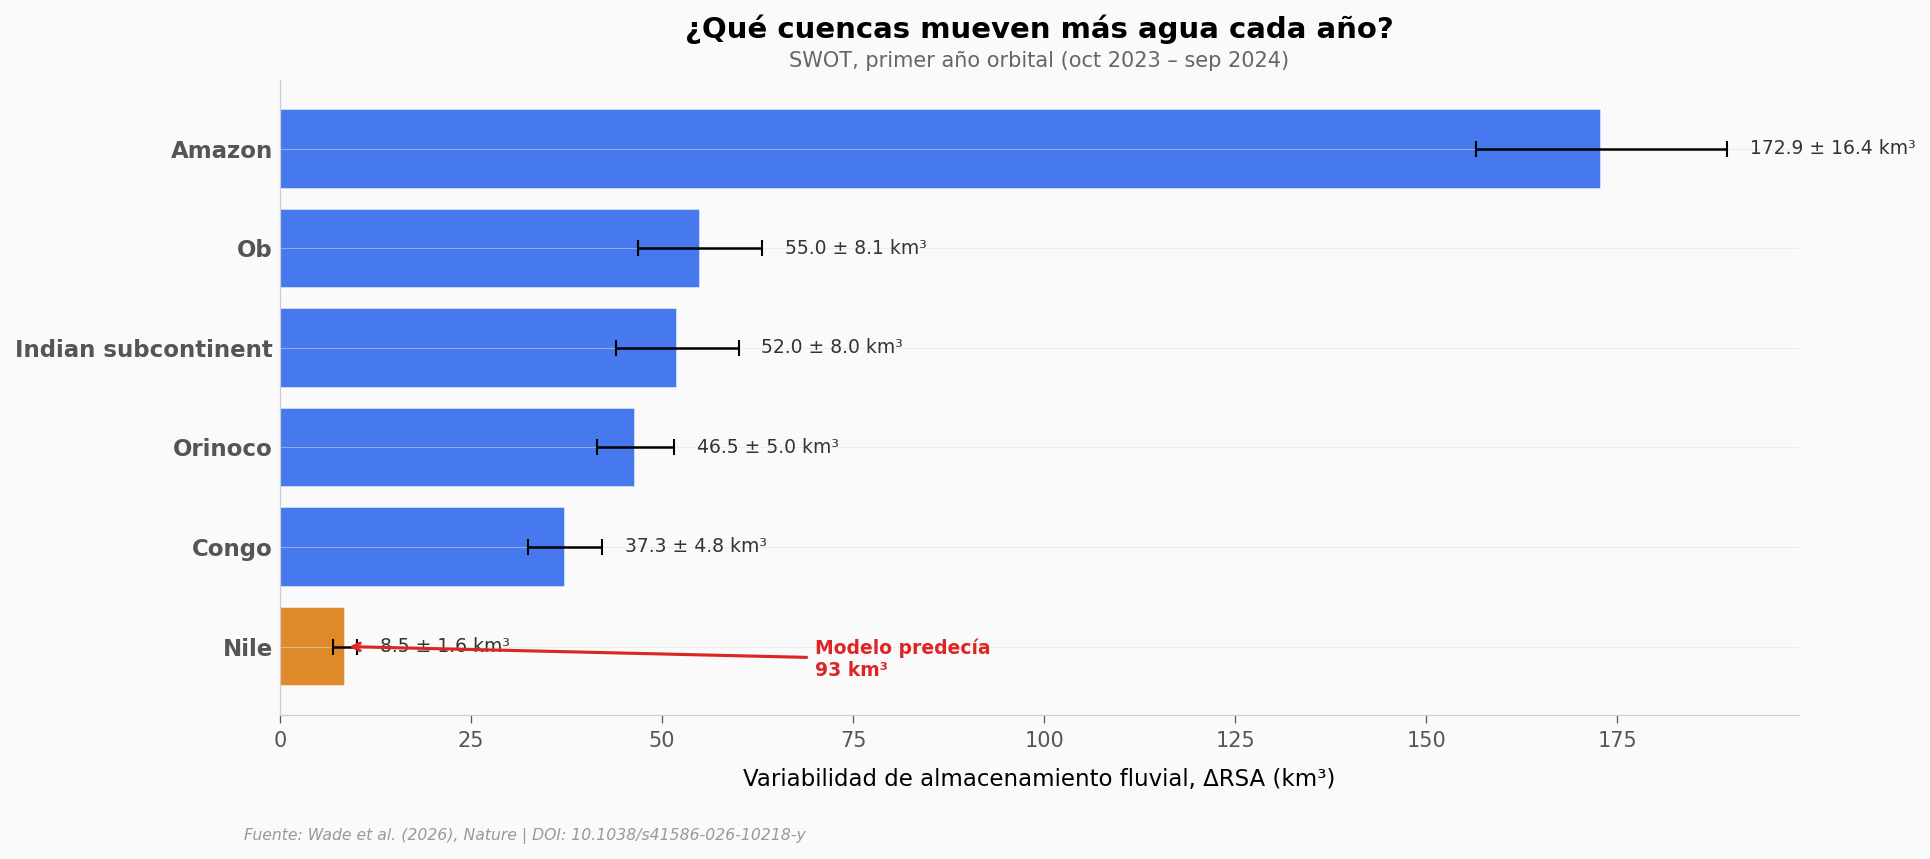

In [2]:
# Gráfica hero: ΔRSA por cuenca
fig, ax = plt.subplots(figsize=(13, 5.5))

cuencas_sorted = cuencas.sort_values('swot_drsa_km3', ascending=True)
y_pos = range(len(cuencas_sorted))
colors = [COLOR_ALERTA if c == 'Nile' else COLOR_SWOT for c in cuencas_sorted['cuenca']]

bars = ax.barh(list(y_pos), cuencas_sorted['swot_drsa_km3'], 
               xerr=cuencas_sorted['swot_error_km3'],
               color=colors, alpha=0.85, edgecolor='white', linewidth=0.8,
               capsize=4, error_kw={'linewidth': 1.2, 'color': '#666666'})

ax.set_yticks(list(y_pos))
ax.set_yticklabels(cuencas_sorted['cuenca'], fontsize=11, fontweight='bold')

# Inline labels con valor
for i, (_, row) in enumerate(cuencas_sorted.iterrows()):
    ax.text(row['swot_drsa_km3'] + row['swot_error_km3'] + 3, i,
            f"{row['swot_drsa_km3']:.1f} ± {row['swot_error_km3']:.1f} km³",
            va='center', fontsize=9, color='#333333')

# Nile annotation
nile_idx = list(cuencas_sorted['cuenca']).index('Nile')
ax.annotate('Modelo predecía\n93 km³', 
            xy=(8.5, nile_idx), xytext=(70, nile_idx - 0.3),
            fontsize=9, color=COLOR_MODELO, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=COLOR_MODELO, lw=1.5))

ax.set_xlabel('Variabilidad de almacenamiento fluvial, ΔRSA (km³)', fontsize=11)
ax.set_title('¿Qué cuencas mueven más agua cada año?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'SWOT, primer año orbital (oct 2023 – sep 2024)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/cuencas_rsa.png', dpi=200, bbox_inches='tight')
plt.show()

El **Amazonas domina**: su ΔRSA (172,9 km³) representa el 55% de toda la variabilidad global. No sorprende — el Amazonas es, con diferencia, la cuenca con mayor descarga del planeta.

Lo inesperado es el **Nilo** (en ámbar). SWOT midió solo 8,5 km³ de variabilidad, cuando los modelos predecían 93 km³. Eso es un 91% menos. Parte de la explicación: la sequía severa de 2023-2024 en el Nilo Azul, y posiblemente la retención de agua por la Gran Presa del Renacimiento de Etiopía (~60 km³ de capacidad).

## El satélite vs los modelos

SWOT no solo midió cuencas individuales — generó la primera estimación global observacional de variabilidad de almacenamiento fluvial. ¿Cómo se compara con lo que los modelos predecían?

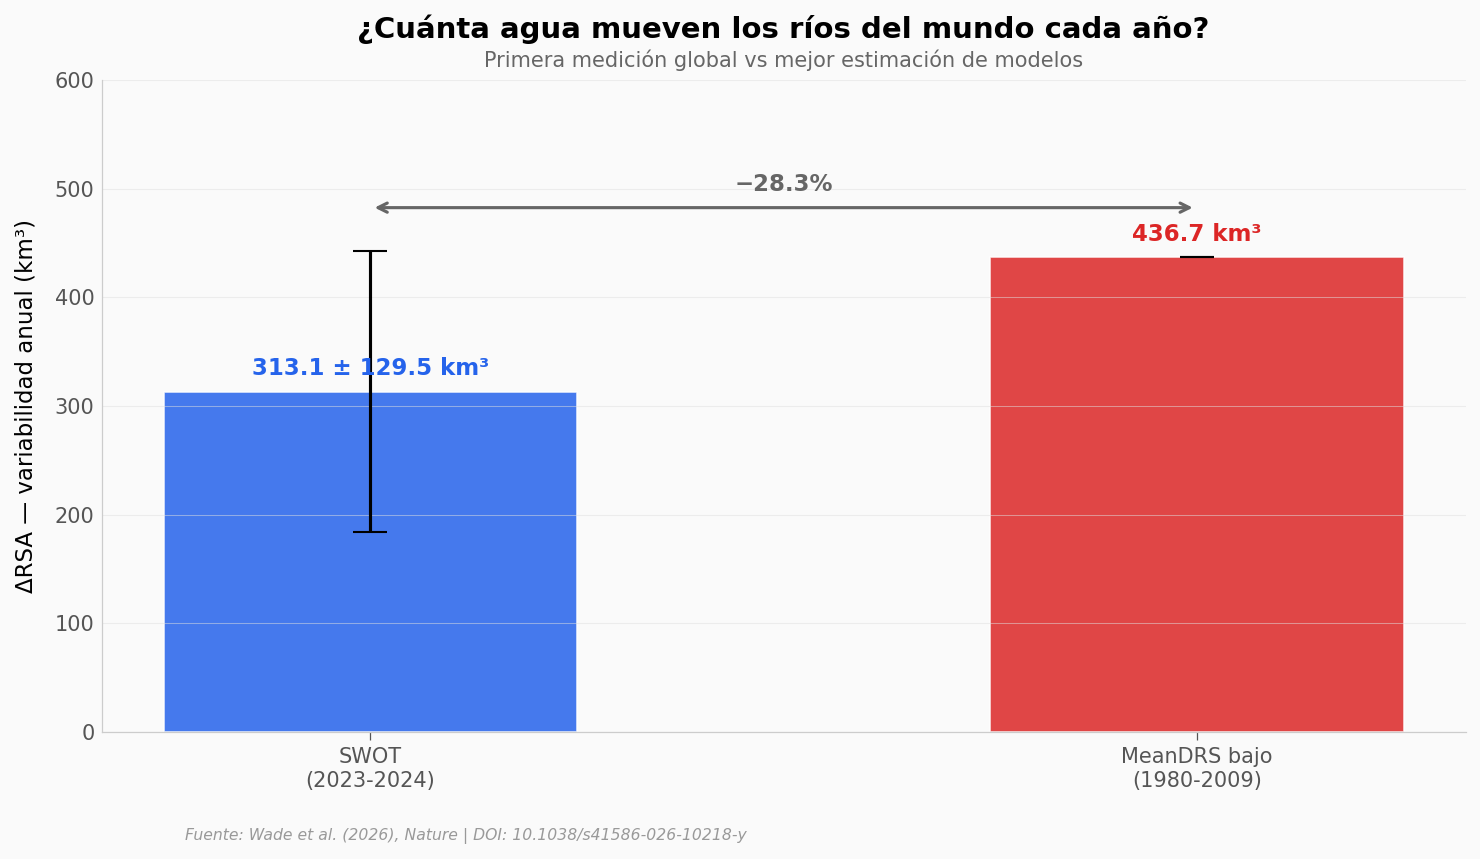

In [3]:
# Gráfica 2: SWOT vs modelos
fig, ax = plt.subplots(figsize=(10, 5.5))

categories = ['SWOT\n(observado)', 'MeanDRS\n(bajo)', 'MeanDRS\nσ rango bajo', 'MeanDRS\nσ rango alto']
values = [DRSA_GLOBAL, MODELO_BAJO, 288 * 2, 721 * 2]  # σ×2 ≈ range for normal
errors = [DRSA_GLOBAL_ERR, 0, 0, 0]
colors_bars = [COLOR_SWOT, COLOR_MODELO, '#BBBBBB', '#BBBBBB']

# Only show SWOT and MeanDRS bajo as main comparison
labels = ['SWOT\n(2023-2024)', 'MeanDRS bajo\n(1980-2009)']
vals = [DRSA_GLOBAL, MODELO_BAJO]
errs = [DRSA_GLOBAL_ERR, 0]
cols = [COLOR_SWOT, COLOR_MODELO]

bars = ax.bar(labels, vals, yerr=errs, color=cols, alpha=0.85,
              edgecolor='white', linewidth=0.8, width=0.5,
              capsize=8, error_kw={'linewidth': 1.5, 'color': '#666666'})

# Inline values
for bar, val, err in zip(bars, vals, errs):
    label = f'{val:.1f} ± {err:.1f}' if err > 0 else f'{val:.1f}'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{label} km³', ha='center', fontsize=11, fontweight='bold',
            color=cols[bars.index(bar)])

# Arrow showing difference
mid_x = 0.5
ax.annotate('', xy=(0, DRSA_GLOBAL + DRSA_GLOBAL_ERR + 40),
            xytext=(1, DRSA_GLOBAL + DRSA_GLOBAL_ERR + 40),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(mid_x, DRSA_GLOBAL + DRSA_GLOBAL_ERR + 55,
        f'−{abs((DRSA_GLOBAL - MODELO_BAJO) / MODELO_BAJO * 100):.1f}%', ha='center', fontsize=11, fontweight='bold', color='#666666')

ax.set_ylabel('ΔRSA — variabilidad anual (km³)', fontsize=11)
ax.set_title('¿Cuánta agua mueven los ríos del mundo cada año?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Primera medición global vs mejor estimación de modelos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_ylim(0, 600)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/swot_vs_modelos.png', dpi=200, bbox_inches='tight')
plt.show()

Los modelos esperaban al menos 436,7 km³ de variabilidad anual. SWOT midió 313,1 km³ — un 28,3% menos. Y la diferencia se mantiene incluso comparando solo los tramos que ambos cubren.

¿Significa que los modelos estaban mal? No necesariamente. La sequía récord del Amazonas en 2024, las limitaciones del satélite en ríos congelados del Ártico, y la frecuencia de revisita (~28 días) probablemente contribuyen. Pero los datos apuntan a limitaciones reales en cómo modelamos la dinámica del agua superficial.

## Los ríos en contexto

Para dimensionar estos números, veamos cuánta agua guardan los ríos comparado con el resto.

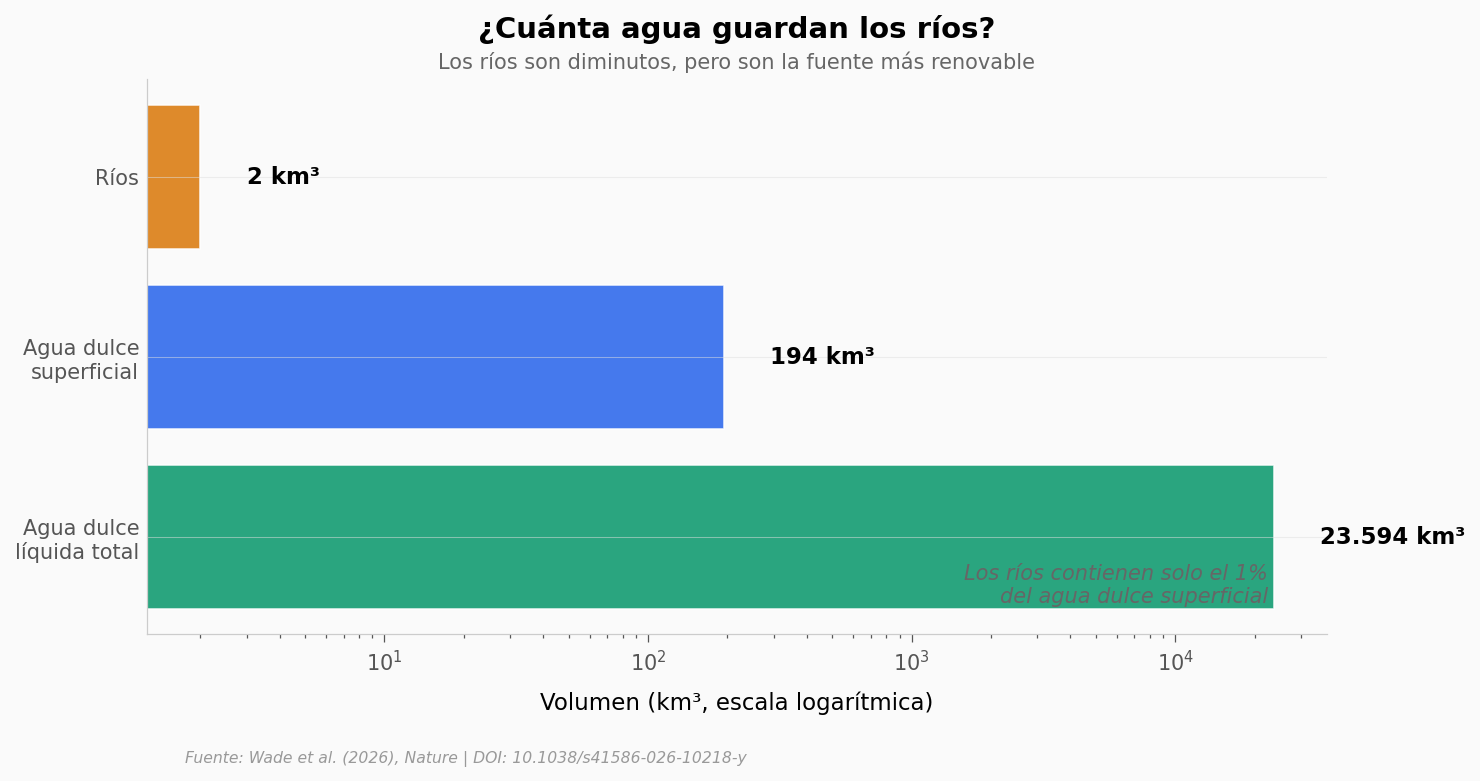

In [4]:
# Gráfica 3: Contexto — ríos en el ciclo del agua
fig, ax = plt.subplots(figsize=(10, 5))

reservorios = ['Agua dulce\nlíquida total', 'Agua dulce\nsuperficial', 'Ríos']
volumenes = [23594, 194, 2]

# Log scale bar chart
bars = ax.barh(reservorios, volumenes, color=[COLOR_CONTEXTO, COLOR_SWOT, COLOR_ALERTA],
               alpha=0.85, edgecolor='white', linewidth=0.8)

ax.set_xscale('log')

# Inline labels
for bar, vol in zip(bars, volumenes):
    # Format with dots for thousands
    if vol >= 1000:
        label = f'{vol:,}'.replace(',', '.') + ' km³'
    else:
        label = f'{vol} km³'
    ax.text(vol * 1.5, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=11, fontweight='bold')

# Highlight rivers' tiny fraction
ax.text(0.95, 0.05, 'Los ríos contienen solo el 1%\ndel agua dulce superficial',
        transform=ax.transAxes, fontsize=10, color='#666666',
        ha='right', va='bottom', style='italic')

ax.set_xlabel('Volumen (km³, escala logarítmica)', fontsize=11)
ax.set_title('¿Cuánta agua guardan los ríos?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Los ríos son diminutos, pero son la fuente más renovable',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/contexto_agua.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan sorprendente es lo del Nilo?

El caso del Nilo es el más llamativo del paper. Los modelos esperaban una cosa. SWOT encontró otra.

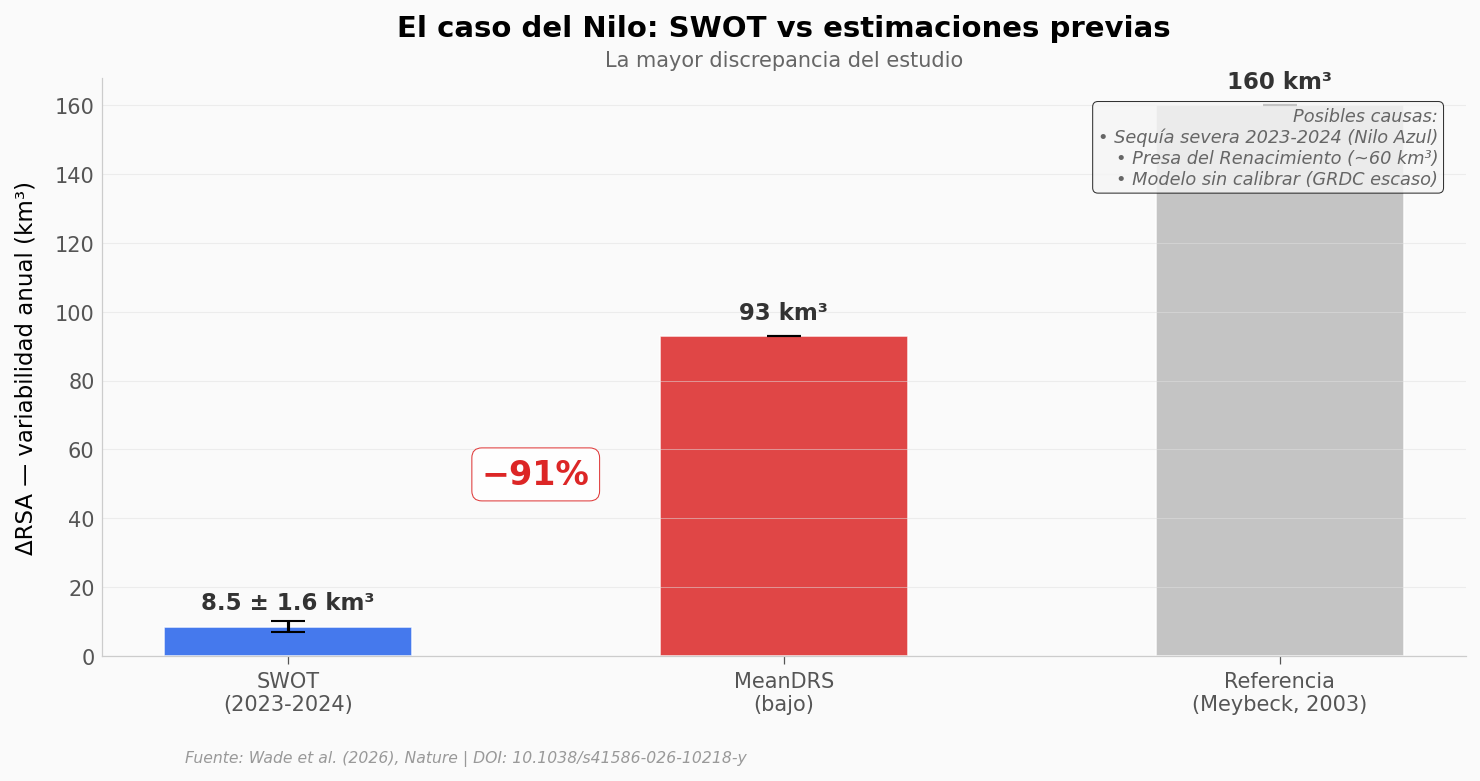

In [5]:
# Gráfica 4: Discrepancia Nilo — SWOT vs estimaciones previas
fig, ax = plt.subplots(figsize=(10, 5))

# Bar comparison for Nile
sources = ['SWOT\n(2023-2024)', 'MeanDRS\n(bajo)', 'Referencia\n(Meybeck, 2003)']
nile_values = [8.5, 93.0, 160.0]
nile_errors = [1.6, 0, 0]
nile_colors = [COLOR_SWOT, COLOR_MODELO, '#BBBBBB']

bars = ax.bar(sources, nile_values, yerr=nile_errors, color=nile_colors,
              alpha=0.85, edgecolor='white', linewidth=0.8, width=0.5,
              capsize=8, error_kw={'linewidth': 1.5, 'color': '#666666'})

# Inline values
for bar, val, err, col in zip(bars, nile_values, nile_errors, nile_colors):
    label = f'{val:.1f} ± {err:.1f}' if err > 0 else f'{val:.0f}'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{label} km³', ha='center', fontsize=11, fontweight='bold', color='#333333')

# Annotations
ax.annotate('−91%', xy=(0.5, 50), fontsize=16, fontweight='bold',
            color=COLOR_MODELO, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=COLOR_MODELO, alpha=0.9))

# Context note
ax.text(0.98, 0.95, 'Posibles causas:\n• Sequía severa 2023-2024 (Nilo Azul)\n• Presa del Renacimiento (~60 km³)\n• Modelo sin calibrar (GRDC escaso)',
        transform=ax.transAxes, fontsize=8.5, color='#666666',
        ha='right', va='top', style='italic',
        bbox=dict(boxstyle='round', facecolor='#f5f5f5', alpha=0.8))

ax.set_ylabel('ΔRSA — variabilidad anual (km³)', fontsize=11)
ax.set_title('El caso del Nilo: SWOT vs estimaciones previas',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'La mayor discrepancia del estudio',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/nilo_discrepancia.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| ΔRSA global = 313,1 ± 129,5 km³ | ✅ | Valor del paper, n = 126.674 reaches |
| SWOT mide 28% menos que modelos | ✅ | 313,1 vs 436,7 km³ = −28,3%, sobre reaches comparables |
| Amazon domina la variabilidad | ✅ | 172,9 km³ = 55% del ΔRSA global |
| Nilo muy por debajo de modelos | ✅ | 8,5 vs 93 km³, pero influyen sequía 2024 + presa |
| Los ríos guardan solo 1% del agua superficial | ✅ | ~2.000 km³ de ~194.000 km³ |

> **Limitaciones:** (1) Datos extraídos del texto del paper, no del dataset SWOT original (~1,9 GB en Zenodo). (2) Solo mostramos 6 de 61 cuencas (las reportadas con valores numéricos en el texto). (3) El primer año de SWOT coincidió con la sequía récord del Amazonas — los valores podrían no representar un año típico. (4) Los valores del Nilo pueden estar afectados por la Gran Presa del Renacimiento de Etiopía.

---

## Ahora tú

1. **¿Por qué la suma de los ΔRSA de las 5 cuencas más grandes supera el ΔRSA global?** Pista: ΔRSA es un rango (max − min). ¿Qué pasa cuando las cuencas pican en meses diferentes?

2. **Si los ríos solo guardan ~2.000 km³ y la variabilidad anual es ~313 km³, ¿qué fracción del almacenamiento total fluctúa cada año?** Pista: `313.1 / 2000`.

3. **¿Cuántos años de observaciones SWOT necesitaríamos para saber si la discrepancia Nilo es por la sequía o es estructural?** El paper sugiere que la misión durará 3 años — ¿será suficiente?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánto fluctúa el almacenamiento total de los ríos cada año?

total_rios_km3 = 2000         # Almacenamiento total (estimación)
drsa_swot = 313.1             # Variabilidad anual medida por SWOT

fraccion = drsa_swot / total_rios_km3 * 100
print(f"Los ríos fluctúan ~{fraccion:.0f}% de su volumen total cada año")
print(f"Eso es {drsa_swot:.0f} km³ de {total_rios_km3:,} km³".replace(',', '.'))
print()

# Top 5 cuencas (sin Nilo) vs global
top5 = 172.9 + 55.0 + 52.0 + 46.5 + 37.3
print(f"Top 5 cuencas (suma de rangos individuales): {top5:.1f} km³")
print(f"ΔRSA global (rango del agregado): {drsa_swot:.1f} km³")
print(f"\n⚠️ La suma ({top5:.1f}) supera el total ({drsa_swot:.1f}) porque ΔRSA")
print(f"mide el rango max−min: no es aditivo entre cuencas con picos en meses distintos.")
print(f"Esto es esperado — no significa que falte agua.")

Los ríos fluctúan ~16% de su volumen total cada año
Eso es 313 km³ de 2.000 km³

Top 5 cuencas (suma de rangos individuales): 363.7 km³
ΔRSA global (rango del agregado): 313.1 km³

⚠️ La suma (363.7) supera el total (313.1) porque ΔRSA
mide el rango max−min: no es aditivo entre cuencas con picos en meses distintos.
Esto es esperado — no significa que falte agua.


---

**Fuente:** Wade et al. (2026). *Wide-swath altimetry maps bank shapes and storage changes in global rivers.* Nature, 651, 99–106.

**DOI:** [10.1038/s41586-026-10218-y](https://doi.org/10.1038/s41586-026-10218-y)

**Datos:** Valores extraídos del texto del paper (Open Access). Dataset completo: [Zenodo 10.5281/zenodo.18344109](https://zenodo.org/records/18344109) (1,9 GB). Código: [GitHub jswade/SWOT-river-volume](https://github.com/jswade/SWOT-river-volume).

**Licencia:** Datos del paper bajo licencia Creative Commons. Notebook CC-BY 4.0.

**Repo:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)